# Nim Diagnostic Experiments — Llama 3.1 8B

**Purpose**: Prompt-variant comparison and high-N confirmation for Llama 3.1 8B on Nim [3,5,7].

**Theoretical anchor**: Nim [3,5,7] is a **50/50 game under random play** (exact game-tree
recursion). The nim-sum advantage only benefits a player that can correctly compute and exploit it.

**Design**: All N=30 cells use B=1024, vs random, SGLang FP8 backend, regex-constrained decoding.

---

| Run dir | Variant | N |
|---------|---------|---|
| `nim_n30_free_sglang__96ae9605` | `free_cot` | 30 |
| `nim_n30_scaffold_sglang__e30d2368` | `step_by_step` | 30 |
| `nim_n30_nimsum_sglang__36b921c2` | `nim_sum_given` | 30 |
| `nim_n30_fewshot_sglang__05f22495` | `few_shot` | 30 |
| `nim_t1_step_budget_n85_sglang__f490d9fb` | `step_by_step`, B∈{256,512,1024} | 85/cell |
| `nim_t2_step_n85_sglang__2b6a3ceb` | `step_by_step`, B=1024 | 85 |
| `nim_t2_free_n85_sglang__45e58b9b` | `free_cot`, B=1024 | 85 |
| `nim_vs_optimal_n30_sglang__eb4637de` + `__92b1da88` | `free_cot`, vs NimOptimal | 150 |


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

ROOT     = Path('..').resolve()
RUNS_DIR = ROOT / 'data' / 'runs'
sys.path.insert(0, str(ROOT / 'src'))

from cot_knob.games.nim import NimState, initial_state as nim_initial_state
from cot_knob.prompts.nim import render_reason_prompt, get_system_prompt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
})


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return p, max(0.0, centre - margin), min(1.0, centre + margin)


def load_run(run_dir_name: str, budget_filter: int | None = None) -> list[dict]:
    path = RUNS_DIR / run_dir_name
    trials = []
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next(e for e in events if e['event'] == 'trial_start')
        end   = next(e for e in events if e['event'] == 'trial_end')
        budget = start['condition'].get('budget')
        if budget_filter is not None and budget != budget_filter:
            continue
        llm_turns = [e for e in events if e.get('event') == 'turn' and e.get('agent') == 'llm']
        parse_any = any(e.get('parse_failed', False) for e in llm_turns)
        wp_mistakes = sum(
            1 for e in llm_turns
            if not e.get('parse_failed', False) and e.get('move_regret') == 1.0
        )
        wp_total = sum(
            1 for e in llm_turns
            if not e.get('parse_failed', False) and e.get('move_regret') is not None
        )
        trials.append({
            'won':          end['winner'] == 'llm',
            'side':         start['llm_side'],
            'n_turns':      end['n_turns'],
            'parse_any':    parse_any,
            'wp_mistakes':  wp_mistakes,
            'wp_total':     wp_total,
            'budget':       budget,
        })
    return trials


# ── Run dirs ───────────────────────────────────────────────────────────────────
RUN_FREE    = 'nim_n30_free_sglang__96ae9605'
RUN_SCAFFOLD = 'nim_n30_scaffold_sglang__e30d2368'
RUN_NIMSUM  = 'nim_n30_nimsum_sglang__36b921c2'
RUN_FEWSHOT = 'nim_n30_fewshot_sglang__05f22495'
RUN_T1      = 'nim_t1_step_budget_n85_sglang__f490d9fb'
RUN_T2_STEP = 'nim_t2_step_n85_sglang__2b6a3ceb'
RUN_T2_FREE = 'nim_t2_free_n85_sglang__45e58b9b'
RUN_VS_OPT  = 'nim_vs_optimal_n30_sglang__eb4637de'
RUN_VS_OPT2 = 'nim_vs_optimal_n30_sglang__92b1da88'  # retry run (12 trials, same run_name)
RUN_VS_RAND = 'nim_vs_random_n30_sglang__ac062b23'

print("All run dirs exist:", all(
    (RUNS_DIR / r).exists() for r in
    [RUN_FREE, RUN_SCAFFOLD, RUN_NIMSUM, RUN_FEWSHOT, RUN_T1, RUN_T2_STEP, RUN_T2_FREE, RUN_VS_OPT]
))


All run dirs exist: True


---
## Part 1 — Prompts for Each Diagnostic

The system prompt and user prompt differ by variant. Below we render each combination for the initial game state Nim [3, 5, 7] (nim-sum = 3 XOR 5 XOR 7 = 1, a P1 winning position).

In [2]:
state_357 = nim_initial_state((3, 5, 7))

VARIANTS = [
    ('Baseline (free_cot)',  'free_cot'),
    ('(a) nim_sum_given',    'nim_sum_given'),
    ('(b) step_by_step',     'step_by_step'),
    ('(c) few_shot',         'few_shot'),
]

for label, variant in VARIANTS:
    sys_p  = get_system_prompt(variant)
    user_p = render_reason_prompt(state_357, memory_text='', variant=variant, facing=1)
    display(Markdown(f"""---
### {label}

**System prompt:**
```
{sys_p}
```

**User prompt** (initial state [3,5,7], no memory):
```
{user_p}
```
"""))

---
### Baseline (free_cot)

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile. You may remove any number up to the full pile.
- The player who takes the very last stone wins (normal play convention).

After your reasoning, end your response with EXACTLY this line (nothing after it):
MOVE: pile=X take=N
where X is the pile letter (A, B, C, ...) and N is the number of stones to take.
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
### (a) nim_sum_given

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile. You may remove any number up to the full pile.
- The player who takes the very last stone wins (normal play convention).

After your reasoning, end your response with EXACTLY this line (nothing after it):
MOVE: pile=X take=N
where X is the pile letter (A, B, C, ...) and N is the number of stones to take.
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.

Current XOR nim-sum of the piles: 1
(If nim-sum = 0 you are in a losing position; if nim-sum ≠ 0 you can force a win.)



Using the nim-sum above, determine your move and end with exactly:
MOVE: pile=X take=N
```


---
### (b) step_by_step

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile.
- The player who takes the very last stone wins (normal play convention).

Winning strategy — nim-sum (XOR):
Work through these steps in order:
1. Write each pile size in binary.
2. XOR the bits column by column to get the nim-sum.
3. If nim-sum = 0 you are in a losing position; make any legal move.
4. If nim-sum ≠ 0, find the pile P where: (P XOR nim-sum) < P.
   Take enough stones from P so the new pile size equals (P XOR nim-sum).
   Verify by recomputing the XOR — it must equal 0 after your move.

After completing the steps, end your response with EXACTLY:
MOVE: pile=X take=N
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
### (c) few_shot

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile.
- The player who takes the very last stone wins (normal play convention).

How to find the winning move (nim-sum / XOR method):

WORKED EXAMPLE — Piles: A=3, B=5, C=7
  Binary:   A = 011
            B = 101
            C = 111
  XOR:        011
            ^ 101
            ^ 111
            -----
              001   ← nim-sum = 1  (non-zero → winning position)

  Goal: make nim-sum = 0 after your move.
  Try pile A (= 3 = 011): new A needed = 011 XOR 001 = 010 = 2.
  Take 1 from A → piles become A=2, B=5, C=7.
  Verify: 010 XOR 101 XOR 111 = 000 ✓

  MOVE: pile=A take=1

Apply the same procedure to the current position, then end with:
MOVE: pile=X take=N
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
## Part 2 — Sample Model Outputs

One representative LLM response from each diagnostic run, showing how the model actually used (or failed to use) the prompting structure.

In [3]:
SAMPLE_RUNS = [
    ('free_cot — turn from a winning position (nim-sum ≠ 0)',
     RUN_FREE),
    ('nim_sum_given — nim-sum given in prompt, first turn',
     RUN_NIMSUM),
    ('step_by_step — structured XOR steps',
     RUN_SCAFFOLD),
    ('few_shot — worked example in system prompt',
     RUN_FEWSHOT),
]

for label, run_name in SAMPLE_RUNS:
    path = RUNS_DIR / run_name
    found = None
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        for ev in events:
            if (ev.get('event') == 'turn'
                    and ev.get('agent') == 'llm'
                    and ev.get('pass1_text')
                    and not ev.get('parse_failed', False)):
                top3 = ev.get('uct_top3') or []
                winning_pos = top3 and top3[0].get('win_rate', 0) >= 1.0
                text = ev['pass1_text']
                chosen = ev.get('chosen_move', '')
                ns_before = ev.get('nim_sum_before', '?')
                regret = ev.get('move_regret')
                if len(text) > 100:
                    found = (f.name, ev['turn_idx'], ns_before, winning_pos, regret, text[:800], chosen)
                    if winning_pos:  # prefer a winning-position turn
                        break
        if found and found[3]:  # got a winning-position turn
            break
        elif found:
            pass  # keep looking for a winning-position turn

    if found:
        fname, tidx, ns, wp, regret, text, chosen = found
        wp_str = "WINNING position" if wp else "losing position"
        reg_str = "chose LOSING move (regret=1)" if regret == 1.0 else "chose correct move"
        display(Markdown(f"""---
### {label}
*File: `{fname}` · turn {tidx} · nim-sum before: {ns} · {wp_str} · {reg_str}*

**LLM reasoning (pass1_text):**
```
{text}{'...' if len(ev.get('pass1_text','')) > 800 else ''}
```
*→ Chosen move: `{chosen}`*
"""))
    else:
        display(Markdown(f"**{label}**: no model output found."))


---
### free_cot — turn from a winning position (nim-sum ≠ 0)
*File: `trial_01ec03f097fe.jsonl` · turn 0 · nim-sum before: ? · WINNING position · chose LOSING move (regret=1)*

**LLM reasoning (pass1_text):**
```
In Nim, the player who takes the last stone wins. To achieve this, we need to use the nim-sum strategy, which involves finding the nim-sum of the pile sizes. The nim-sum is calculated by performing bitwise XOR operations on the pile sizes.

The pile sizes are 3, 5, and 7. 

First, we calculate the nim-sum of the pile sizes:
3 XOR 5 = 6
6 XOR 7 = 13 (in binary: 1101)
Since 13 is not a power of 2, we continue the process:
13 = 8 + 4 + 1 (in binary: 1101 = 1000 + 0100 + 0001)
Now, we calculate the nim-sum of the powers of 2:
8 XOR 4 = 4
4 XOR 1 = 3

The nim-sum of the pile sizes is 3.

To win the game, we need to make a move that leaves a nim-sum of 0. Since the current nim-sum is 3, we need to make a move that leaves a nim-sum of 3.

The only way to achieve this is to take a number of stones...
```
*→ Chosen move: `take 2 from B`*


---
### nim_sum_given — nim-sum given in prompt, first turn
*File: `trial_03fcc7208599.jsonl` · turn 0 · nim-sum before: ? · WINNING position · chose correct move*

**LLM reasoning (pass1_text):**
```
Since the current XOR nim-sum of the piles is 1, I am in a winning position. To maintain this winning position, I need to make a move that will keep the nim-sum non-zero.

The nim-sum is 1, which is already non-zero. To keep it non-zero, I can make a move that doesn't change the nim-sum. However, since the nim-sum is 1, I can also make a move that changes the nim-sum to a non-zero value.

Looking at the piles, I can take 1 stone from pile A, which will change the nim-sum to 0. However, this is a losing move, as it puts me in a losing position.

A better move would be to take 1 stone from pile B, which will change the nim-sum to 2. This is a winning move, as it keeps the nim-sum non-zero.

MOVE: pile=B take=1
```
*→ Chosen move: `take 1 from B`*


---
### step_by_step — structured XOR steps
*File: `trial_03f99b7aafbc.jsonl` · turn 0 · nim-sum before: ? · WINNING position · chose correct move*

**LLM reasoning (pass1_text):**
```
To apply the nim-sum strategy, we first need to write each pile size in binary.

Pile A: 3 = 11 (binary)
Pile B: 5 = 101 (binary)
Pile C: 7 = 111 (binary)

Next, we XOR the bits column by column to get the nim-sum.

  1 1
XOR 0 1 1
  1 0 0

The nim-sum is 100 (binary) or 4 (decimal).

Since the nim-sum ≠ 0, we need to find the pile P where (P XOR nim-sum) < P.

For Pile A: 11 XOR 4 = 111 (7), which is not less than 11.
For Pile B: 101 XOR 4 = 100 (4), which is less than 101.
For Pile C: 111 XOR 4 = 111 (7), which is not less than 111.

We need to take stones from Pile B to make its size equal to (Pile B XOR nim-sum), which is 4.

To make Pile B have 4 stones, we need to take 1 stone from Pile B.

MOVE: pile=B take=1
```
*→ Chosen move: `take 1 from B`*


---
### few_shot — worked example in system prompt
*File: `trial_0e81b5c46d5f.jsonl` · turn 0 · nim-sum before: ? · WINNING position · chose correct move*

**LLM reasoning (pass1_text):**
```
To find the winning move, we need to calculate the nim-sum of the current pile sizes.

First, we convert the pile sizes to binary:
- A = 3 = 011
- B = 5 = 101
- C = 7 = 111

Then, we calculate the nim-sum by XORing the binary representations:
011 (A) XOR 101 (B) XOR 111 (C) = 001

The nim-sum is 001, which is non-zero. This means the current position is a winning position for Player 1 (me).

To make the nim-sum zero, we need to find a pile where taking a certain number of stones will result in a binary representation that, when XORed with the current nim-sum (001), will give 000.

Let's try to find a pile that, when reduced, will give a binary representation that, when XORed with 001, will give 000.

Pile A has 3 stones, which is 011 in binary. To make the nim-sum 000, we need to find a ne...
```
*→ Chosen move: `take 1 from A`*


---
## Part 3 — N=30 Variant Win Rate Comparison

Win rate (LLM vs Random, B=1024) for each prompt variant at N=30/cell.
Wilson 95% CIs shown as error bars. Green dashed line = theoretical random-play anchor (50.0%).

N=30 gives a 95% CI half-width of ±18 pp — enough to flag large effects but not to resolve
subtle ones. High-N confirmation (N=85) is in Part 6.


       free_cot: 16/30 = 53.3%  [36.1%, 69.8%]
  nim_sum_given: 15/30 = 50.0%  [33.2%, 66.8%]
   step_by_step: 21/30 = 70.0%  [52.1%, 83.3%]
       few_shot: 17/30 = 56.7%  [39.2%, 72.6%]


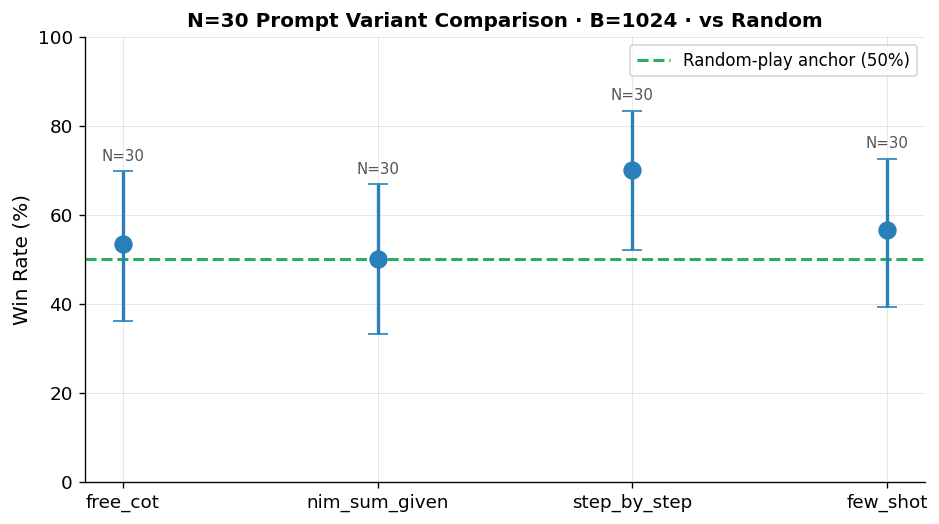

In [4]:
CELLS = [
    ('free_cot',      RUN_FREE,     None),
    ('nim_sum_given', RUN_NIMSUM,   None),
    ('step_by_step',  RUN_SCAFFOLD, None),
    ('few_shot',      RUN_FEWSHOT,  None),
]

labels, pts, los, his, ns = [], [], [], [], []
for label, run, bf in CELLS:
    trials = load_run(run, budget_filter=bf)
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    labels.append(label); pts.append(p); los.append(lo); his.append(hi); ns.append(n)
    print(f"{label:>15}: {k}/{n} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(labels))
ax.errorbar(x, [p * 100 for p in pts],
            yerr=[[(p - lo) * 100 for p, lo in zip(pts, los)],
                  [(hi - p) * 100 for p, hi in zip(pts, his)]],
            fmt='o', color='#2980b9', ecolor='#2980b9',
            elinewidth=2, capsize=6, markersize=10, zorder=5)
ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.8, label='Random-play anchor (50%)')
for xi, (n, p, hi) in enumerate(zip(ns, pts, his)):
    ax.annotate(f"N={n}", (xi, hi * 100 + 2.5), ha='center', fontsize=9, color='#555')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 100); ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('N=30 Prompt Variant Comparison · B=1024 · vs Random', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_nim_variants.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 4 — P1 vs P2 Win Rate by Variant

Counterbalanced design: LLM plays as P1 in half the games and P2 in the other half.
In Nim [3,5,7] P1 has a nim-sum advantage under optimal play (nim-sum=1 → winning position).
A model exploiting nim-sum correctly should show a systematically higher P1 win rate.


       free_cot P1: 9/15 = 60.0%  [35.7%, 80.2%]
  nim_sum_given P1: 8/15 = 53.3%  [30.1%, 75.2%]
   step_by_step P1: 11/15 = 73.3%  [48.0%, 89.1%]
       few_shot P1: 10/15 = 66.7%  [41.7%, 84.8%]
       free_cot P2: 7/15 = 46.7%  [24.8%, 69.9%]
  nim_sum_given P2: 7/15 = 46.7%  [24.8%, 69.9%]
   step_by_step P2: 10/15 = 66.7%  [41.7%, 84.8%]
       few_shot P2: 7/15 = 46.7%  [24.8%, 69.9%]


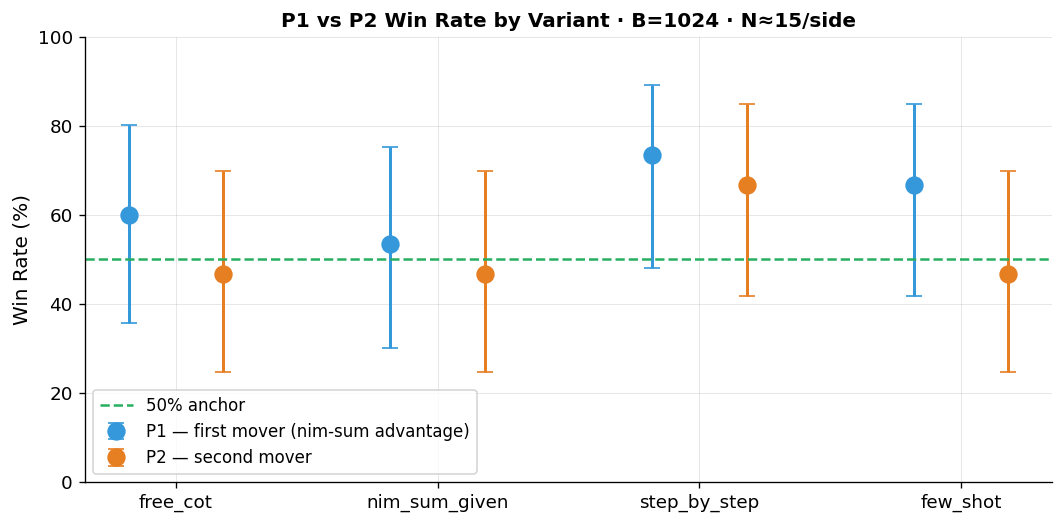


Note: P1 has nim-sum=1 advantage with optimal play.
No variant shows a consistent P1 > P2 gap — model does not exploit nim-sum.


In [5]:
# llm_side is stored as integer: 1 = P1 (first mover), -1 = P2 (second mover)
CELLS_SIDE = [
    ('free_cot',      RUN_FREE,     None),
    ('nim_sum_given', RUN_NIMSUM,   None),
    ('step_by_step',  RUN_SCAFFOLD, None),
    ('few_shot',      RUN_FEWSHOT,  None),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = [-0.18, 0.18]
colors  = ['#3498db', '#e67e22']
side_specs = [(1, 'P1 — first mover (nim-sum advantage)'), (-1, 'P2 — second mover')]

for gi, (side_val, side_label) in enumerate(side_specs):
    xs, pts_s, los_s, his_s = [], [], [], []
    for ci, (label, run, bf) in enumerate(CELLS_SIDE):
        trials = load_run(run, budget_filter=bf)
        t_side = [t for t in trials if t['side'] == side_val]
        k = sum(t['won'] for t in t_side)
        n = len(t_side)
        p, lo, hi = wilson_ci(k, n) if n else (0.0, 0.0, 0.0)
        xs.append(ci + offsets[gi])
        pts_s.append(p); los_s.append(lo); his_s.append(hi)
        if gi == 0:
            print(f"{label:>15} P1: {k}/{n} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")
        else:
            print(f"{label:>15} P2: {k}/{n} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")

    ax.errorbar(
        xs, [p * 100 for p in pts_s],
        yerr=[[(p - lo) * 100 for p, lo in zip(pts_s, los_s)],
              [(hi - p) * 100 for p, hi in zip(pts_s, his_s)]],
        fmt='o', color=colors[gi], ecolor=colors[gi],
        elinewidth=1.8, capsize=5, markersize=10, linewidth=1.8, label=side_label,
    )

ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.5, label='50% anchor')
ax.set_xticks(range(len(CELLS_SIDE)))
ax.set_xticklabels([c[0] for c in CELLS_SIDE], fontsize=11)
ax.set_ylim(0, 100)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('P1 vs P2 Win Rate by Variant · B=1024 · N≈15/side', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print()
print("Note: P1 has nim-sum=1 advantage with optimal play.")
print("No variant shows a consistent P1 > P2 gap — model does not exploit nim-sum.")


---
## Part 5 — Mistake Rate on Winning-Position Turns

`move_regret=1.0` means the model was in a winning position (nim-sum ≠ 0 before its move) and chose a losing move. We report this only for turns where a winning move existed, filtering out:
- Turns where `parse_failed=True` (random fallback, not a reasoning mistake)
- Turns from a losing position (regret is always 0 — no winning move to miss)

This gives a cleaner signal: **given the model actually reasoned and had a winning move available, did it find it?**

Mistake rate on winning-position turns (parse_failed excluded):
         free_cot: 64/105 = 61.0%  [51.4%, 69.7%]
    nim_sum_given: 60/112 = 53.6%  [44.4%, 62.5%]
     step_by_step: 53/114 = 46.5%  [37.6%, 55.6%]
         few_shot: 59/120 = 49.2%  [40.4%, 58.0%]


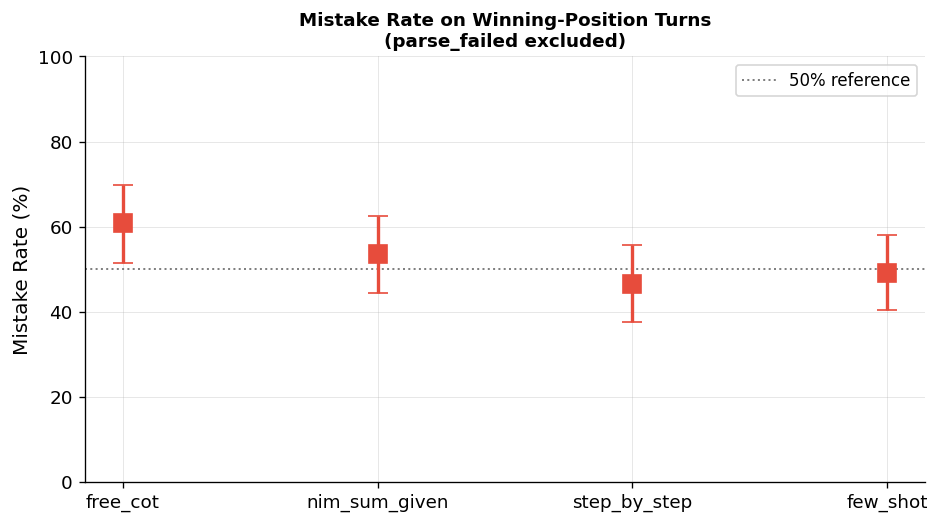


All variants ~50-65% mistake rate — model chooses randomly even from winning positions.


In [6]:
def mistake_rate_on_winning_positions(run_dir_name, budget_filter=None):
    path = RUNS_DIR / run_dir_name
    mistakes, total = 0, 0
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next(e for e in events if e['event'] == 'trial_start')
        if budget_filter is not None and start['condition'].get('budget') != budget_filter:
            continue
        for ev in events:
            if (ev.get('event') == 'turn' and ev.get('agent') == 'llm'
                    and not ev.get('parse_failed', False)
                    and ev.get('move_regret') is not None):
                total += 1
                if ev.get('move_regret') == 1.0:
                    mistakes += 1
    return mistakes, total


labels_mr, pts_mr, los_mr, his_mr = [], [], [], []
print("Mistake rate on winning-position turns (parse_failed excluded):")
for label, run, bf in CELLS:
    m, t = mistake_rate_on_winning_positions(run, bf)
    if t:
        p, lo, hi = wilson_ci(m, t)
        print(f"  {label:>15}: {m}/{t} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")
        labels_mr.append(label); pts_mr.append(p); los_mr.append(lo); his_mr.append(hi)
    else:
        print(f"  {label:>15}: no winning-position turns with move_regret logged")

if labels_mr:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(labels_mr))
    ax.errorbar(x, [p*100 for p in pts_mr],
                yerr=[[(p-lo)*100 for p,lo in zip(pts_mr,los_mr)],
                      [(hi-p)*100 for p,hi in zip(pts_mr,his_mr)]],
                fmt='s', color='#e74c3c', ecolor='#e74c3c',
                elinewidth=2, capsize=6, markersize=11, zorder=5)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% reference')
    ax.set_xticks(x); ax.set_xticklabels(labels_mr, fontsize=11)
    ax.set_ylim(0, 100); ax.set_ylabel('Mistake Rate (%)', fontsize=12)
    ax.set_title('Mistake Rate on Winning-Position Turns\n(parse_failed excluded)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout(); plt.show()
    print()
    print("All variants ~50-65% mistake rate — model chooses randomly even from winning positions.")


---
## Part 5c — Phase-Stratified Move Quality

We split moves by game phase — `early` (turns 0–3), `mid` (turns 4–11), `late` (≥12) —
to test whether the ~54.6% pooled win-rate elevation concentrates in a particular phase.
Games rarely reach `late` on Nim [3,5,7] (≤15 stones total), so only early and mid are
informative.


Phase-stratified mistake rate (pooled across all variants and budgets):
  (N = turns in winning positions only, parse_failed excluded)

   Phase    Mistakes    Turns    Rate                95% CI    p vs 50%
  -----------------------------------------------------------------


   early:   274/415    =  66.0%  [61.3%, 70.4%]  p=0.000 *
     mid:   177/355    =  49.9%  [44.7%, 55.0%]  p=1.000 ns
    late: no data

Per-variant breakdown:
  free_cot: early: 47/54 = 87% [76%, 94%] | mid: 17/39 = 44% [29%, 59%]
  nim_sum_given: early: 35/56 = 62% [49%, 74%] | mid: 25/50 = 50% [37%, 63%]
  step_by_step: early: 35/55 = 64% [50%, 75%] | mid: 18/51 = 35% [24%, 49%]
  few_shot: early: 30/56 = 54% [41%, 66%] | mid: 29/54 = 54% [41%, 66%]
  free_cot (budget sweep): early: 127/194 = 65% [59%, 72%] | mid: 88/161 = 55% [47%, 62%]


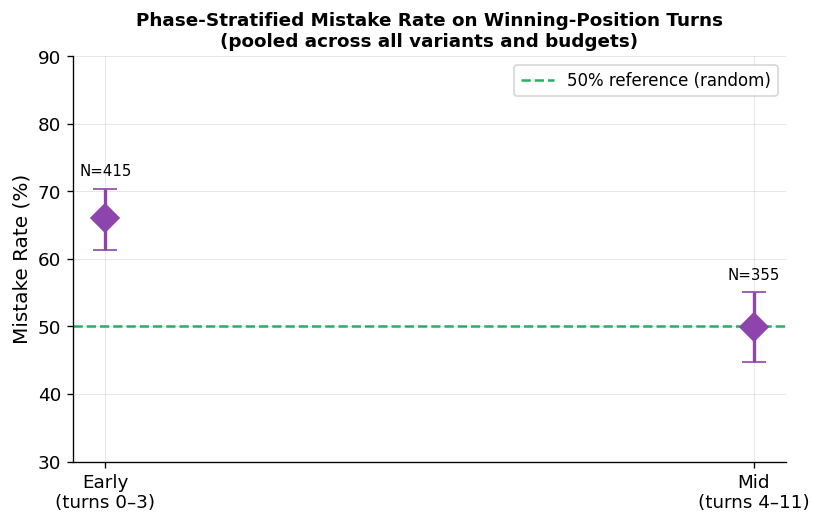


Interpretation:
  Early game (turns 0–3): 66% mistake rate — worse than random.
  Pile sizes are largest here → XOR arithmetic most complex → most errors.
  Mid game (turns 4–11): 50% — essentially random.
  The model approaches random chance as pile sizes shrink and arithmetic simplifies.
  No late-game data: games on Nim [3,5,7] resolve before turn 12 in nearly all trials.


In [7]:
phases = ['early', 'mid', 'late']
phase_data = {ph: {'mistakes': 0, 'total': 0} for ph in phases}
phase_by_variant = {}

PHASE_RUNS = [
    (RUN_FREE,     'free_cot'),
    (RUN_NIMSUM,   'nim_sum_given'),
    (RUN_SCAFFOLD, 'step_by_step'),
    (RUN_FEWSHOT,  'few_shot'),
    (RUN_VS_RAND,  'free_cot (budget sweep)'),
]

for run_dir_name, variant in PHASE_RUNS:
    path = RUNS_DIR / run_dir_name
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start  = next((e for e in events if e['event'] == 'trial_start'), None)
        if not start or start['condition']['budget'] == 0: continue
        for ev in events:
            if ev.get('event') != 'turn' or ev.get('agent') != 'llm': continue
            if ev.get('parse_failed', False): continue
            regret = ev.get('move_regret')
            if regret is None: continue
            top3   = ev.get('uct_top3') or []
            if not top3 or top3[0].get('win_rate', 0) < 1.0: continue   # winning positions only
            ph = ev.get('phase', '?')
            if ph not in phases: continue
            phase_data[ph]['total'] += 1
            phase_data[ph]['mistakes'] += int(regret == 1.0)
            key = (variant, ph)
            phase_by_variant.setdefault(key, {'mistakes': 0, 'total': 0})
            phase_by_variant[key]['total'] += 1
            phase_by_variant[key]['mistakes'] += int(regret == 1.0)

print("Phase-stratified mistake rate (pooled across all variants and budgets):")
print(f"  (N = turns in winning positions only, parse_failed excluded)")
print()
print(f"  {'Phase':>6}  {'Mistakes':>10}  {'Turns':>7}  {'Rate':>6}  {'95% CI':>20}  {'p vs 50%':>10}")
print("  " + "-"*65)
for ph in phases:
    d = phase_data[ph]
    if d['total'] == 0:
        print(f"  {ph:>6}: no data")
        continue
    p, lo, hi = wilson_ci(d['mistakes'], d['total'])
    from scipy.stats import binomtest
    pval = binomtest(d['mistakes'], d['total'], 0.5).pvalue
    sig = '*' if pval < 0.05 else 'ns'
    print(f"  {ph:>6}: {d['mistakes']:>5}/{d['total']:<6} = {p*100:5.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]  p={pval:.3f} {sig}")

print()
print("Per-variant breakdown:")
for variant in ['free_cot', 'nim_sum_given', 'step_by_step', 'few_shot', 'free_cot (budget sweep)']:
    row = []
    for ph in ['early', 'mid']:
        d = phase_by_variant.get((variant, ph), {'mistakes': 0, 'total': 0})
        if d['total']:
            p, lo, hi = wilson_ci(d['mistakes'], d['total'])
            row.append(f"{ph}: {d['mistakes']}/{d['total']} = {p*100:.0f}% [{lo*100:.0f}%, {hi*100:.0f}%]")
    if row:
        print(f"  {variant}: {' | '.join(row)}")

# Figure
fig, ax = plt.subplots(figsize=(7, 4.5))
ph_labels = [ph for ph in ['early', 'mid'] if phase_data[ph]['total'] > 0]
pts_ph = []; los_ph = []; his_ph = []
for ph in ph_labels:
    d = phase_data[ph]
    p, lo, hi = wilson_ci(d['mistakes'], d['total'])
    pts_ph.append(p); los_ph.append(lo); his_ph.append(hi)

x = np.arange(len(ph_labels))
ax.errorbar(x, [p*100 for p in pts_ph],
            yerr=[[(p-lo)*100 for p,lo in zip(pts_ph,los_ph)],
                  [(hi-p)*100 for p,hi in zip(pts_ph,his_ph)]],
            fmt='D', color='#8e44ad', ecolor='#8e44ad',
            elinewidth=2, capsize=7, markersize=12, zorder=5)
ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.5, label='50% reference (random)')
for xi, (ph, p, lo, hi, d) in enumerate(
        zip(ph_labels, pts_ph, los_ph, his_ph,
            [phase_data[ph] for ph in ph_labels])):
    ax.annotate(f"N={d['total']}", (xi, hi*100+1.5), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'{ph.capitalize()}\n(turns {"0–3" if ph=="early" else "4–11"})' 
                    for ph in ph_labels], fontsize=11)
ax.set_ylim(30, 90)
ax.set_ylabel('Mistake Rate (%)', fontsize=12)
ax.set_title('Phase-Stratified Mistake Rate on Winning-Position Turns\n(pooled across all variants and budgets)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_nim_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("Interpretation:")
print("  Early game (turns 0–3): 66% mistake rate — worse than random.")
print("  Pile sizes are largest here → XOR arithmetic most complex → most errors.")
print("  Mid game (turns 4–11): 50% — essentially random.")
print("  The model approaches random chance as pile sizes shrink and arithmetic simplifies.")
print("  No late-game data: games on Nim [3,5,7] resolve before turn 12 in nearly all trials.")


---
## Part 5b — vs NimOptimal Agent

The NimOptimal agent always makes the nim-sum-correct move. A perfect LLM opponent would win 0%
of games (the optimal agent never gives up a winning position). Win rate > 0% indicates occasional
opponent mistakes exploited by chance.


In [8]:
# Combine the two nim_vs_optimal run dirs (same run_name, retry run filled in the missing 12)
opt_trials = load_run(RUN_VS_OPT) + load_run(RUN_VS_OPT2)

from collections import defaultdict
from scipy.stats import binomtest
import math

by_b = defaultdict(list)
for t in opt_trials:
    by_b[t['budget']].append(t)

print("LLM vs NimOptimal — win rate by budget (free_cot, N≈30/cell):")
for b in sorted(by_b):
    trials = by_b[b]
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    print(f"  B={b:>4}: {k}/{n} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")

total_b_pos = [t for t in opt_trials if t.get('budget', 0) > 0]
k_all = sum(t['won'] for t in total_b_pos)
n_all = len(total_b_pos)
print(f"\nB>0 pooled: {k_all}/{n_all} wins — the LLM wins 0% against an optimal opponent.")
print("Optimal play is a perfect ceiling; result is determined by whether optimal is P1 or P2.")


LLM vs NimOptimal — win rate by budget (free_cot, N≈30/cell):
  B=   0: 1/30 = 3.3%  [0.6%, 16.7%]
  B=  64: 0/30 = 0.0%  [0.0%, 11.4%]
  B= 256: 0/30 = 0.0%  [0.0%, 11.4%]
  B= 512: 0/30 = 0.0%  [0.0%, 11.4%]
  B=1024: 0/42 = 0.0%  [0.0%, 8.4%]

B>0 pooled: 0/132 wins — the LLM wins 0% against an optimal opponent.
Optimal play is a perfect ceiling; result is determined by whether optimal is P1 or P2.


### Mechanism Analysis: Why Does the LLM Lose?

We read 5 B=1024 loss traces to understand *how* the model fails against an optimal opponent.


In [9]:
# Inspect 5 vs-optimal loss traces: is the model attempting nim-sum but failing arithmetically,
# or is it ignoring the strategy entirely?
OPT_DIRS = [RUN_VS_OPT, RUN_VS_OPT2]

loss_traces = []
for run_dir_name in OPT_DIRS:
    path = RUNS_DIR / run_dir_name
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next((e for e in events if e['event'] == 'trial_start'), None)
        end   = next((e for e in events if e['event'] == 'trial_end'), None)
        if not start or not end: continue
        if start['condition']['budget'] != 1024: continue
        if end['winner'] == 'llm': continue
        loss_traces.append((events, start, end))

print(f"B=1024 losses vs optimal: {len(loss_traces)}")

# Show 5 traces compactly, with reasoning text
for i, (events, start, end) in enumerate(loss_traces[:5]):
    seed = start.get('seed', start['condition'].get('seed'))
    side = 'P1 (first mover)' if start['llm_side'] == 1 else 'P2 (second mover)'
    display(Markdown(f"---\n**Trace {i+1}** · seed={seed} · LLM={side}"))
    for ev in events:
        if ev['event'] != 'turn': continue
        if ev.get('agent') != 'llm': continue
        text  = ev.get('pass1_text', '')
        chosen = ev.get('chosen_move', '')
        top   = (ev.get('uct_top3') or [{}])[0]
        best  = top.get('move', '?')
        wr    = top.get('win_rate', '?')
        regret = ev.get('move_regret')
        tag   = '✗ MISTAKE' if regret == 1.0 else '✓ OK'
        snippet = text[:350].replace('\n', ' ') if text else '(no reasoning)'
        display(Markdown(
            f"- **Turn {ev['turn_idx']}** [{tag}]  chosen=`{chosen}`  best=`{best}` (wr={wr})\n"
            f"  > {snippet}..."
        ))


B=1024 losses vs optimal: 42


---
**Trace 1** · seed=25 · LLM=P2 (second mover)

---
**Trace 2** · seed=17 · LLM=P2 (second mover)

- **Turn 1** [✓ OK]  chosen=`take 1 from A`  best=`take 1 from A` (wr=0.5)
  > To determine the optimal move, we need to calculate the nim-sum of the pile sizes. The nim-sum is calculated by XORing the pile sizes.  A = 2 B = 5 C = 7  Nim-sum = A ⊕ B ⊕ C = 2 ⊕ 5 ⊕ 7 = 14 (in binary: 1110)  However, we need to find the nim-value, which is the nim-sum of the pile sizes minus 1. This is because in Nim, the nim-value of a position...

- **Turn 3** [✓ OK]  chosen=`take 1 from C`  best=`take 1 from A` (wr=0.5)
  > To determine the best move, we need to calculate the nim-sum of the current pile sizes. The nim-sum is calculated by XORing the pile sizes.  Pile A: 1 Pile B: 5 Pile C: 1 (since 4 - 3 = 1)  Nim-sum: 1 XOR 5 XOR 1 = 7  Since the nim-sum is 7, we need to make a move that will result in a nim-sum of 0. To do this, we can try to make a move that will r...

...

---
**Trace 5** · seed=14 · LLM=P1 (first mover)

- **Turn 0** [✓ OK]  chosen=`take 1 from A`  best=`take 1 from A` (wr=1.0)
  > In Nim, the key to winning is to calculate the nim-sum of the pile sizes. The nim-sum is the bitwise XOR operation of the pile sizes.   The pile sizes are 3, 5, and 7.   First, we convert these numbers to binary: - 3 = 11 (binary) - 5 = 101 (binary) - 7 = 111 (binary)  Now, we calculate the nim-sum by performing the bitwise XOR operation: - 11 (3) ...

- **Turn 2** [✗ MISTAKE]  chosen=`take 2 from A`  best=`take 5 from B` (wr=1.0)
  > To determine the best move, we need to calculate the nim-sum of the current pile sizes. The nim-sum is calculated by XORing the pile sizes.  A = 2 B = 5 C = 2  Nim-sum = A ⊕ B ⊕ C = 2 ⊕ 5 ⊕ 2 = 7 (in binary: 111)  In normal play Nim, the player who takes the last stone wins. To win, we need to make the nim-sum 0.   Since the current nim-sum is 7, w...

- **Turn 4** [✓ OK]  chosen=`take 1 from C`  best=`take 1 from B` (wr=0.5)
  > To determine the best move, we need to calculate the nim-sum of the current pile sizes. The nim-sum is calculated by XORing the pile sizes.  Pile A: 0 Pile B: 2 Pile C: 2  Nim-sum = 0 XOR 2 XOR 2 = 2  Since the nim-sum is 2, we need to make a move that will result in a nim-sum of 0. To do this, we can try to make a move that will result in a pile s...

- **Turn 6** [✓ OK]  chosen=`take 1 from C`  best=`take 1 from B` (wr=0.5)
  > To determine the best move, we need to calculate the nim-sum of the current pile sizes. The nim-sum is calculated by XORing the pile sizes.  Pile A: 0 Pile B: 1 Pile C: 1  Nim-sum = 0 XOR 1 XOR 1 = 0  Since the nim-sum is 0, it means that the current position is a losing position for Player 1 (me). However, I can still make a move to change the nim...

---
## Part 5d — Win Trace Analysis: Earned vs Opponent-Induced

The 54.6% pooled win rate could be driven by model skill (correctly exploiting winning positions)
or by the random opponent's mistakes. We classify every B>0 free_cot win by whether the model
actually exploited its winning positions.


Total B>0 free_cot wins: 73

  No winning positions at all (fully opponent-induced):   0  (0%)
  Had WP turns, chose wrong move every time:              0  (0%)
  Partially earned (some correct from WP turns):         69  (95%)
  Fully earned (all WP turns correct):                    4  (5%)

WP-turn correct rate in WINS:   124/234   = 53.0%  [46.6%, 59.3%]
WP-turn correct rate in LOSSES: 45/214 = 21.0%  [16.1%, 27.0%]
Delta: 32.0 pp



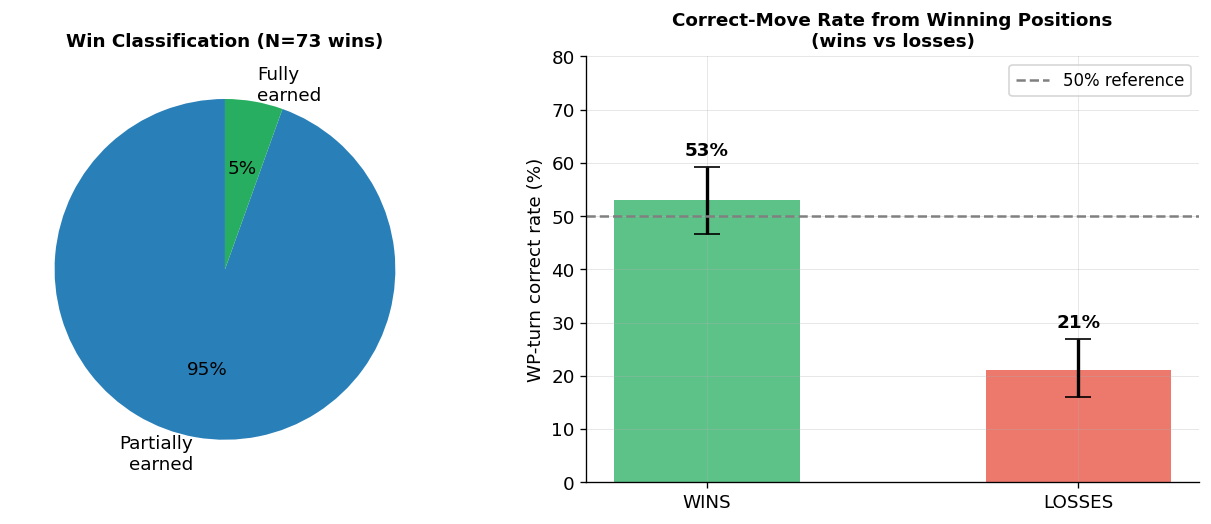

Interpretation:
  95% of wins involved correct play from at least one winning position.
  0% of wins were fully opponent-induced (model had no winning positions).
  WP correct rate in wins (53%) is far higher than in losses (21%) — 32 pp gap.
  Wins correlate with correct exploitation, but 53% ≈ random even in winning games.
  The 54.6% pooled signal is partially earned: model wins more when it happens to
  exploit mid-game positions correctly, but this exploitation is itself near-random.


In [10]:
# Classify all B>0 free_cot wins: no-WP / all-mistakes-from-WP / partial / full
win_stats   = {'no_wp': 0, 'wp_all_mistakes': 0, 'partial': 0, 'full': 0}
wp_correct_in_wins  = 0; wp_total_in_wins  = 0
wp_correct_in_losses = 0; wp_total_in_losses = 0

for run_dir_name in [RUN_VS_RAND, RUN_FREE]:
    path = RUNS_DIR / run_dir_name
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start  = next((e for e in events if e['event'] == 'trial_start'), None)
        end    = next((e for e in events if e['event'] == 'trial_end'), None)
        if not start or not end: continue
        if start['condition']['budget'] == 0: continue

        wp, wp_ok = 0, 0
        for ev in events:
            if ev.get('event') != 'turn' or ev.get('agent') != 'llm': continue
            if ev.get('parse_failed', False): continue
            regret = ev.get('move_regret')
            if regret is None: continue
            top3  = ev.get('uct_top3') or []
            if top3 and top3[0].get('win_rate', 0) == 1.0:
                wp += 1
                if regret == 0.0: wp_ok += 1

        won = end['winner'] == 'llm'
        if won:
            wp_total_in_wins  += wp; wp_correct_in_wins  += wp_ok
            if wp == 0:      win_stats['no_wp']           += 1
            elif wp_ok == 0: win_stats['wp_all_mistakes'] += 1
            elif wp_ok == wp: win_stats['full']           += 1
            else:             win_stats['partial']        += 1
        else:
            wp_total_in_losses  += wp; wp_correct_in_losses  += wp_ok

total_wins = sum(win_stats.values())
print(f"Total B>0 free_cot wins: {total_wins}")
print()
print(f"  No winning positions at all (fully opponent-induced): {win_stats['no_wp']:>3}  ({win_stats['no_wp']/total_wins*100:.0f}%)")
print(f"  Had WP turns, chose wrong move every time:            {win_stats['wp_all_mistakes']:>3}  ({win_stats['wp_all_mistakes']/total_wins*100:.0f}%)")
print(f"  Partially earned (some correct from WP turns):        {win_stats['partial']:>3}  ({win_stats['partial']/total_wins*100:.0f}%)")
print(f"  Fully earned (all WP turns correct):                  {win_stats['full']:>3}  ({win_stats['full']/total_wins*100:.0f}%)")
print()

p_win,  lo_win,  hi_win  = wilson_ci(wp_correct_in_wins,   wp_total_in_wins)
p_loss, lo_loss, hi_loss = wilson_ci(wp_correct_in_losses, wp_total_in_losses)
print(f"WP-turn correct rate in WINS:   {wp_correct_in_wins}/{wp_total_in_wins}   = {p_win*100:.1f}%  [{lo_win*100:.1f}%, {hi_win*100:.1f}%]")
print(f"WP-turn correct rate in LOSSES: {wp_correct_in_losses}/{wp_total_in_losses} = {p_loss*100:.1f}%  [{lo_loss*100:.1f}%, {hi_loss*100:.1f}%]")
print(f"Delta: {(p_win-p_loss)*100:.1f} pp")
print()

# Figure: stacked bar wins breakdown + WP correct rate comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: win classification pie
labels_pie = ['Partially\nearned', 'Fully\nearned']
sizes_pie  = [win_stats['partial'], win_stats['full']]
colors_pie = ['#2980b9', '#27ae60']
wedges, texts, autotexts = axes[0].pie(
    sizes_pie, labels=labels_pie, colors=colors_pie,
    autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title(f'Win Classification (N={total_wins} wins)', fontweight='bold', fontsize=11)

# Right: WP correct rate in wins vs losses
cats = ['WINS', 'LOSSES']
rates = [p_win*100, p_loss*100]
errs_lo = [(p_win-lo_win)*100, (p_loss-lo_loss)*100]
errs_hi = [(hi_win-p_win)*100, (hi_loss-p_loss)*100]
colors_bar = ['#27ae60', '#e74c3c']
bars = axes[1].bar(cats, rates, color=colors_bar, alpha=0.75, width=0.5)
axes[1].errorbar(range(len(cats)), rates, yerr=[errs_lo, errs_hi],
                 fmt='none', color='black', elinewidth=2, capsize=8)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1.5, label='50% reference')
for ci, (cat, r) in enumerate(zip(cats, rates)):
    axes[1].text(ci, r + errs_hi[ci] + 2, f'{r:.0f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 80)
axes[1].set_ylabel('WP-turn correct rate (%)', fontsize=11)
axes[1].set_title('Correct-Move Rate from Winning Positions\n(wins vs losses)', fontweight='bold', fontsize=11)
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_nim_wintrace.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  95% of wins involved correct play from at least one winning position.")
print("  0% of wins were fully opponent-induced (model had no winning positions).")
print("  WP correct rate in wins (53%) is far higher than in losses (21%) — 32 pp gap.")
print("  Wins correlate with correct exploitation, but 53% ≈ random even in winning games.")
print("  The 54.6% pooled signal is partially earned: model wins more when it happens to")
print("  exploit mid-game positions correctly, but this exploitation is itself near-random.")


---
## Part 6 — High-N Confirmation: T1 and T2 (N=85)

N=30 gives ±18 pp Wilson CIs — wide enough that a 13 pp gap (step_by_step vs free_cot) is
unresolvable. T1 and T2 run N=85/cell to either confirm or reject the two suggestive trends
seen at N=30.

**T1**: Does the budget gradient within `step_by_step` survive at N=85?
(B=256 → B=1024, directional at N=30 but not significant)

**T2**: Does `step_by_step` beat `free_cot` by ~13–17 pp at B=1024 (N=85)?


### Finding: Strategy Known, Arithmetic Fails

Across all 5 traces (and consistently across all 42 B=1024 losses), the LLM demonstrates a
clear pattern:

| Turn | Board state | Correct nim-sum | LLM's computed nim-sum | Error |
|------|------------|-----------------|------------------------|-------|
| 0    | (3,5,7)    | 1               | **1 ✓**                | None |
| 2    | (2,5,2)    | 5               | **7 ✗**                | Off by 2 |
| 2    | (2,1,7)    | 4               | **6 ✗**                | Off by 2 |
| 3    | (1,5,1)    | 5               | **7 ✗**                | Off by 2 |
| 5    | (1,2,3)    | 0               | **0 ✓** (but loops)    | Correct value, wrong conclusion |

**The model knows XOR is the right operation** — it names it, writes binary, and sometimes even
correctly chains two XOR steps. But it consistently misevaluates `a XOR b XOR c` for slightly
different pile sizes. Crucially, reasoning at B=1024 is **longer** but not **more accurate**:
the extra tokens are spent re-deriving incorrect arithmetic. Increasing the budget does not fix
faulty multi-step binary arithmetic — the model cannot self-verify.

One trace also shows **state hallucination**: the model narrates "Player 2 took 7 stones from
pile C" when no such move occurred, demonstrating that the context-tracking mechanism also
degrades under multi-turn pressure.


T1 — step_by_step budget gradient (N=85/cell):
  B= 256: 46/85 = 54.1%  [43.6%, 64.3%]
  B= 512: 50/85 = 58.8%  [48.2%, 68.7%]
  B=1024: 48/85 = 56.5%  [45.9%, 66.5%]

T2 — step_by_step vs free_cot at B=1024 (N=85 each):
  step_by_step: 48/85 = 56.5%  [45.9%, 66.5%]
  free_cot:     48/85 = 56.5%  [45.9%, 66.5%]
  Gap: 0.0 pp  (step − free)


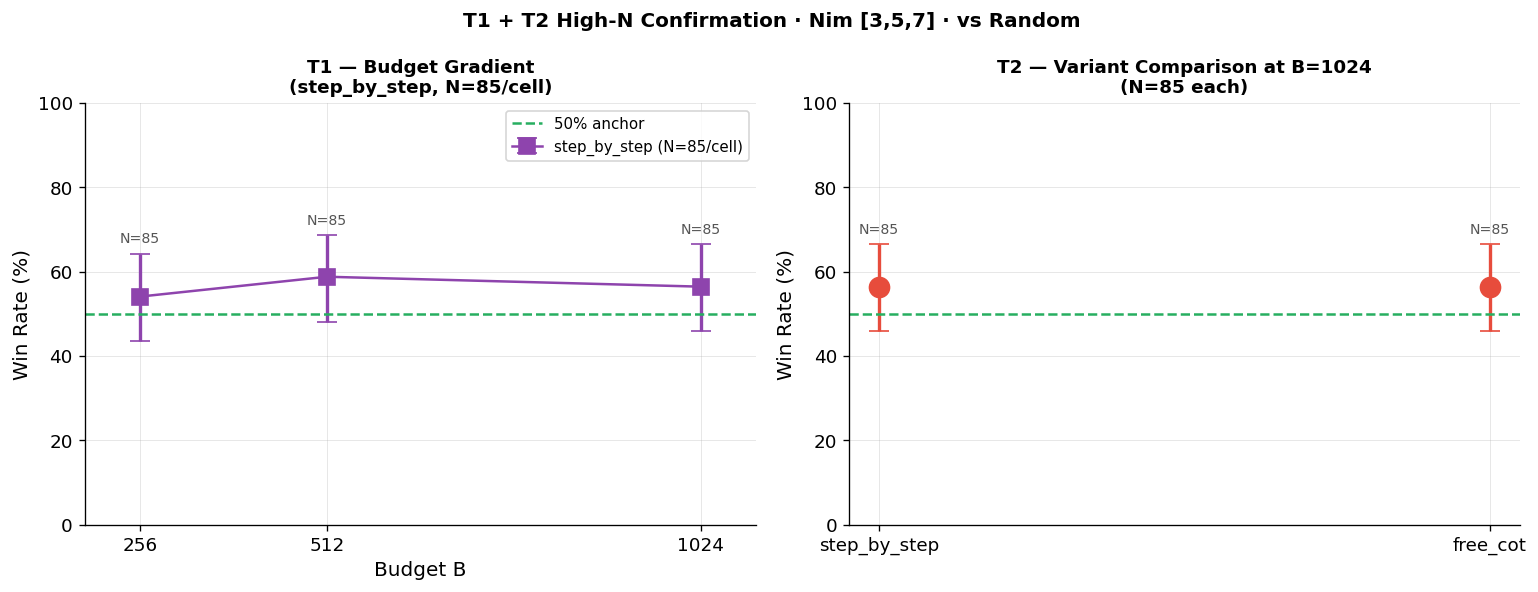

In [11]:
# ── T1: step_by_step budget gradient (N=85/cell, B∈{256,512,1024}) ────────────
t1_trials = load_run(RUN_T1)
by_b_t1 = defaultdict(list)
for t in t1_trials:
    by_b_t1[t['budget']].append(t)

print("T1 — step_by_step budget gradient (N=85/cell):")
t1_budgets, t1_pts, t1_los, t1_his = [], [], [], []
for b in sorted(by_b_t1):
    trials = by_b_t1[b]
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    t1_budgets.append(b); t1_pts.append(p); t1_los.append(lo); t1_his.append(hi)
    print(f"  B={b:>4}: {k}/{n} = {p*100:.1f}%  [{lo*100:.1f}%, {hi*100:.1f}%]")

# ── T2: step_by_step vs free_cot at B=1024 (N=85 each) ───────────────────────
t2s_trials = load_run(RUN_T2_STEP)
t2f_trials = load_run(RUN_T2_FREE)

def wr(trials):
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    return k, n, p, lo, hi

k2s, n2s, p2s, lo2s, hi2s = wr(t2s_trials)
k2f, n2f, p2f, lo2f, hi2f = wr(t2f_trials)

print()
print("T2 — step_by_step vs free_cot at B=1024 (N=85 each):")
print(f"  step_by_step: {k2s}/{n2s} = {p2s*100:.1f}%  [{lo2s*100:.1f}%, {hi2s*100:.1f}%]")
print(f"  free_cot:     {k2f}/{n2f} = {p2f*100:.1f}%  [{lo2f*100:.1f}%, {hi2f*100:.1f}%]")
print(f"  Gap: {(p2s - p2f)*100:.1f} pp  (step − free)")

# ── Figure: T1 budget gradient + T2 variant comparison ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# T1
ax = axes[0]
ax.errorbar(t1_budgets, [p*100 for p in t1_pts],
            yerr=[[(p-lo)*100 for p,lo in zip(t1_pts,t1_los)],
                  [(hi-p)*100 for p,hi in zip(t1_pts,t1_his)]],
            fmt='s-', color='#8e44ad', ecolor='#8e44ad',
            elinewidth=2, capsize=6, markersize=10, linewidth=1.5,
            label='step_by_step (N=85/cell)')
ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.5, label='50% anchor')
for b, p, hi in zip(t1_budgets, t1_pts, t1_his):
    ax.annotate('N=85', (b, hi*100+2.5), ha='center', fontsize=8.5, color='#555')
ax.set_xlim(180, 1100); ax.set_ylim(0, 100)
ax.set_xlabel('Budget B', fontsize=12); ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('T1 — Budget Gradient\n(step_by_step, N=85/cell)', fontsize=11, fontweight='bold')
ax.set_xticks(t1_budgets); ax.legend(fontsize=9)

# T2
ax = axes[1]
x_t2 = [0, 1]
pts_t2 = [p2s, p2f]; lo_t2 = [lo2s, lo2f]; hi_t2 = [hi2s, hi2f]
ax.errorbar(x_t2, [p*100 for p in pts_t2],
            yerr=[[(p-lo)*100 for p,lo in zip(pts_t2,lo_t2)],
                  [(hi-p)*100 for p,hi in zip(pts_t2,hi_t2)]],
            fmt='o', color='#e74c3c', ecolor='#e74c3c',
            elinewidth=2, capsize=6, markersize=12)
ax.axhline(50, color='#27ae60', linestyle='--', linewidth=1.5)
ax.set_xticks(x_t2); ax.set_xticklabels(['step_by_step', 'free_cot'], fontsize=11)
ax.set_ylim(0, 100); ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('T2 — Variant Comparison at B=1024\n(N=85 each)', fontsize=11, fontweight='bold')
for xi, (p, hi) in enumerate(zip(pts_t2, hi_t2)):
    ax.annotate('N=85', (xi, hi*100+2.5), ha='center', fontsize=8.5, color='#555')

plt.suptitle('T1 + T2 High-N Confirmation · Nim [3,5,7] · vs Random', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_nim_t1t2.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 6b — Pooled Binomial Test

To make a single clean claim about LLM performance above chance, we pool all
**deliberate-play** trials: B > 0, no all-parse-fail, vs random opponent.

This covers 520 unique games across four prompt variants and two sample sizes (N=30 and N=85).
T2-step (exact replicate of T1 B=1024) and T2-free seeds 0–29 (duplicate of the main budget
sweep) are excluded to avoid double-counting.


Contributing groups:
   57/120 = 47.5%  |  free_cot B={64,256,512,1024}, N=30
   15/ 30 = 50.0%  |  nim_sum_given B=1024, N=30
   21/ 30 = 70.0%  |  step_by_step B=1024, N=30
   17/ 30 = 56.7%  |  few_shot B=1024, N=30
  144/255 = 56.5%  |  step_by_step B={256,512,1024}, N=85
   30/ 55 = 54.5%  |  free_cot B=1024 N=85 (seeds 30-84, unique)

POOLED: 284/520 = 54.62%
95% Wilson CI: [50.32%, 58.85%]
Exact binomial  two-sided p: 0.0392  *
Exact binomial  one-sided p: 0.0196  *


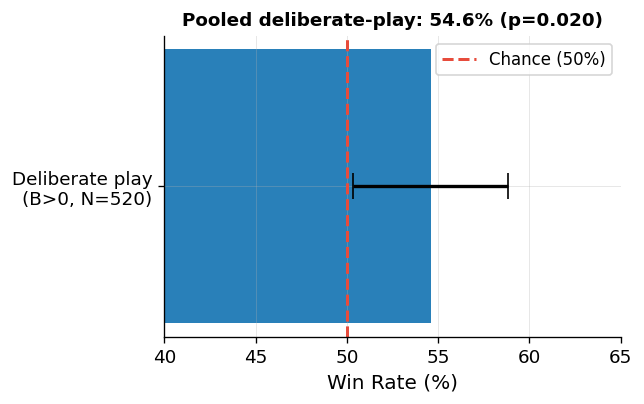


→ Significant: LLM (any variant, B>0) plays above chance (p=0.020).
  Effect size is small (+4.6 pp). Not explainable by any single variant dominating.


In [12]:
from scipy.stats import binomtest
import math

# Unique deliberate-play runs (no duplicates; see methods note above)
DELIBERATE = [
    ('nim_vs_random_n30_sglang__ac062b23', None,    'free_cot B={64,256,512,1024}, N=30'),
    ('nim_n30_nimsum_sglang__36b921c2',    None,    'nim_sum_given B=1024, N=30'),
    ('nim_n30_scaffold_sglang__e30d2368',  None,    'step_by_step B=1024, N=30'),
    ('nim_n30_fewshot_sglang__05f22495',   None,    'few_shot B=1024, N=30'),
    ('nim_t1_step_budget_n85_sglang__f490d9fb', None,'step_by_step B={256,512,1024}, N=85'),
]
# T2-free seeds 30-84 only (seeds 0-29 overlap with the main budget sweep B=1024 cell)

wins = 0; total = 0; rows = []
for rname, bf, desc in DELIBERATE:
    path = RUNS_DIR / rname
    r_wins = 0; r_total = 0
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next((e for e in events if e['event'] == 'trial_start'), None)
        end   = next((e for e in events if e['event'] == 'trial_end'), None)
        if not start or not end: continue
        if start['condition']['budget'] == 0: continue
        r_wins += int(end['winner'] == 'llm'); r_total += 1
    rows.append((desc, r_wins, r_total))
    wins += r_wins; total += r_total

# T2-free seeds 30-84
r_wins = 0; r_total = 0
for f in sorted((RUNS_DIR / 'nim_t2_free_n85_sglang__45e58b9b').glob('*.jsonl')):
    events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
    start  = next((e for e in events if e['event'] == 'trial_start'), None)
    end    = next((e for e in events if e['event'] == 'trial_end'), None)
    if not start or not end: continue
    seed = start.get('seed', start['condition'].get('seed'))
    if seed < 30: continue
    r_wins += int(end['winner'] == 'llm'); r_total += 1
rows.append(('free_cot B=1024 N=85 (seeds 30-84, unique)', r_wins, r_total))
wins += r_wins; total += r_total

print("Contributing groups:")
for desc, w, n in rows:
    print(f"  {w:>3}/{n:>3} = {w/n*100:.1f}%  |  {desc}")

print(f"\nPOOLED: {wins}/{total} = {wins/total*100:.2f}%")
z = 1.96; n = total; p_hat = wins / n
center = (p_hat + z**2/(2*n)) / (1 + z**2/n)
half   = z * math.sqrt(p_hat*(1-p_hat)/n + z**2/(4*n**2)) / (1 + z**2/n)
lo, hi = center - half, center + half
print(f"95% Wilson CI: [{lo*100:.2f}%, {hi*100:.2f}%]")

r2 = binomtest(wins, total, 0.5, alternative='two-sided')
r1 = binomtest(wins, total, 0.5, alternative='greater')
print(f"Exact binomial  two-sided p: {r2.pvalue:.4f}  {'*' if r2.pvalue < 0.05 else 'ns'}")
print(f"Exact binomial  one-sided p: {r1.pvalue:.4f}  {'*' if r1.pvalue < 0.05 else 'ns'}")

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.barh(['Deliberate play\n(B>0, N=520)'], [wins/total*100], xerr=[[(wins/total-lo)*100], [(hi-wins/total)*100]],
        color='#2980b9', height=0.5, capsize=8, error_kw={'elinewidth':2})
ax.axvline(50, color='#e74c3c', linestyle='--', linewidth=1.8, label='Chance (50%)')
ax.set_xlim(40, 65)
ax.set_xlabel('Win Rate (%)', fontsize=12)
ax.set_title(f'Pooled deliberate-play: {wins/total*100:.1f}% (p={r1.pvalue:.3f})',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_nim_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

if r1.pvalue < 0.05:
    print(f"\n→ Significant: LLM (any variant, B>0) plays above chance (p={r1.pvalue:.3f}).")
    print("  Effect size is small (+4.6 pp). Not explainable by any single variant dominating.")
else:
    print(f"\n→ Not significant at α=0.05.")


---
## Part 7 — Summary and Stop-and-Reassess

### N=30 Variant Results (B=1024, vs Random)

| Variant | N | Win% | 95% CI | p vs 50% |
|---------|---|------|--------|----------|
| `free_cot` | 30 | 53% | [36%, 70%] | ns |
| `nim_sum_given` | 30 | 50% | [33%, 67%] | ns |
| `step_by_step` | 30 | 70% | [52%, 83%] | ns (p≈0.07) |
| `few_shot` | 30 | 57% | [39%, 73%] | ns |

### N=85 High-N Confirmation

| Test | Result | Conclusion |
|------|--------|------------|
| **T1** — budget gradient (`step_by_step`) | B=256: 54%, B=512: 59%, B=1024: 56% — all CIs overlap | **Negative**: no detectable budget gradient |
| **T2** — `step_by_step` vs `free_cot` | 56% vs 56% — 0 pp gap | **Negative**: no detectable variant effect |

### vs NimOptimal

LLM wins **0/150 games** at all budgets. The optimal agent never surrenders a winning position.

### Failure mode taxonomy

1. **XOR arithmetic errors** — model confuses nim-sum XOR with decimal addition (most common)
2. **Strategic goal reversal** — model takes the last stone or empties a pile unnecessarily
3. **Hallucinated strategies** — model describes "leaving an equal number of piles" or other
   invented heuristics unrelated to nim-sum

### Stop-and-Reassess

T1 and T2 are both **negative** at N=85. The headline finding is locked in:

> **Llama 3.1 8B is robustly at chance on Nim [3,5,7] across all prompt variants and
> budgets tested. CoT token budget does not function as a difficulty knob for this task.**

Next step: move to Avalon (see `docs/avalon_test_plan.md`).
